In [26]:
import os


folders = [
    'data/raw',
    'data/cleaned',
    'charts'
]


for folder in folders:
    os.makedirs(folder, exist_ok=True)

print('Project folders created successfully!')


Project folders created successfully!


In [2]:
import pandas as pd
df = pd.read_csv('data/raw/medical_noshow.csv')

df.head()


,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [3]:

print('Shape:', df.shape)


print('Total appointments:', df.shape[0])


print('Total columns:', df.shape[1])


print('\nColumn names:')
print(df.columns.tolist())


Shape: (110527, 14)
Total appointments: 110527
Total columns: 14

Column names:
['PatientId', 'AppointmentID', 'Gender', 'ScheduledDay', 'AppointmentDay', 'Age', 'Neighbourhood', 'Scholarship', 'Hipertension', 'Diabetes', 'Alcoholism', 'Handcap', 'SMS_received', 'No-show']


In [4]:

print(df.dtypes)


df.info()


PatientId         float64
AppointmentID       int64
Gender             object
ScheduledDay       object
AppointmentDay     object
Age                 int64
Neighbourhood      object
Scholarship         int64
Hipertension        int64
Diabetes            int64
Alcoholism          int64
Handcap             int64
SMS_received        int64
No-show            object
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  object 
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   

In [5]:
# Check how many missing values exist in each column
print('Missing values per column:')
print(df.isnull().sum())

# Show missing values as a percentage of total rows
print('\nMissing value percentage:')
missing_percent = (df.isnull().sum() / len(df)) * 100
print(missing_percent.round(2))

# Visual check — True means missing, False means present
print('\nAny missing values?', df.isnull().values.any())


Missing values per column:
PatientId         0
AppointmentID     0
Gender            0
ScheduledDay      0
AppointmentDay    0
Age               0
Neighbourhood     0
Scholarship       0
Hipertension      0
Diabetes          0
Alcoholism        0
Handcap           0
SMS_received      0
No-show           0
dtype: int64

Missing value percentage:
PatientId         0.0
AppointmentID     0.0
Gender            0.0
ScheduledDay      0.0
AppointmentDay    0.0
Age               0.0
Neighbourhood     0.0
Scholarship       0.0
Hipertension      0.0
Diabetes          0.0
Alcoholism        0.0
Handcap           0.0
SMS_received      0.0
No-show           0.0
dtype: float64

Any missing values? False


In [6]:

df_no_nulls = df.dropna()
print('Rows after dropping nulls:', len(df_no_nulls))


df = df[df['Age'] >= 0]
print('Rows after removing invalid ages:', len(df))


Rows after dropping nulls: 110527
Rows after removing invalid ages: 110526


In [25]:
# Count duplicate rows
print('Number of duplicate rows:', df.duplicated().sum())

# View the duplicate rows (if any)
print(df[df.duplicated()])

# Remove duplicate rows, keep the first occurrence
df = df.drop_duplicates()
print('Rows after removing duplicates:', len(df))


Number of duplicate rows: 0
Empty DataFrame
Columns: [patientid, appointmentid, gender, scheduledday, appointmentday, age, neighbourhood, scholarship, hypertension, diabetes, alcoholism, handicap, sms_received, no_show, waiting_days, no_show_binary, age_group, appointment_dayofweek, gender_encoded]
Index: []
Rows after removing duplicates: 71959


In [8]:
# See current column names
print('Before:', df.columns.tolist())

# Rename all columns
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace('-', '_')
df.columns = df.columns.str.replace(' ', '_')

# Fix specific column name typos
df = df.rename(columns={
    'hipertension': 'hypertension',
    'handcap': 'handicap',
    'no_show': 'no_show'
})

print('After:', df.columns.tolist())



Before: ['PatientId', 'AppointmentID', 'Gender', 'ScheduledDay', 'AppointmentDay', 'Age', 'Neighbourhood', 'Scholarship', 'Hipertension', 'Diabetes', 'Alcoholism', 'Handcap', 'SMS_received', 'No-show']
After: ['patientid', 'appointmentid', 'gender', 'scheduledday', 'appointmentday', 'age', 'neighbourhood', 'scholarship', 'hypertension', 'diabetes', 'alcoholism', 'handicap', 'sms_received', 'no_show']


In [9]:

df['scheduledday'] = pd.to_datetime(df['scheduledday'])
df['appointmentday'] = pd.to_datetime(df['appointmentday'])
df['waiting_days'] = (df['appointmentday'] - df['scheduledday']).dt.days


df = df[df['waiting_days'] >= 0]

print('Date columns converted successfully!')
print(df[['scheduledday', 'appointmentday', 'waiting_days']].head())


Date columns converted successfully!
                scheduledday            appointmentday  waiting_days
5  2016-04-27 08:36:51+00:00 2016-04-29 00:00:00+00:00             1
6  2016-04-27 15:05:12+00:00 2016-04-29 00:00:00+00:00             1
7  2016-04-27 15:39:58+00:00 2016-04-29 00:00:00+00:00             1
9  2016-04-27 12:48:25+00:00 2016-04-29 00:00:00+00:00             1
10 2016-04-27 14:58:11+00:00 2016-04-29 00:00:00+00:00             1


In [10]:

print('Gender unique values:', df['gender'].unique())


df['gender'] = df['gender'].str.upper()


print('No-show unique values:', df['no_show'].unique())


df['no_show_binary'] = df['no_show'].map({'Yes': 1, 'No': 0})

print('Standardisation complete!')
print(df[['gender', 'no_show', 'no_show_binary']].head())


Gender unique values: ['F' 'M']
No-show unique values: ['No' 'Yes']
Standardisation complete!
   gender no_show  no_show_binary
5       F      No               0
6       F     Yes               1
7       F     Yes               1
9       F      No               0
10      F      No               0


In [11]:
# Save the cleaned DataFrame to a new CSV file
df.to_csv('data/cleaned/medical_noshow_cleaned.csv', index=False)

# index=False means don't save the row numbers as a column

print('Cleaned dataset saved!')
print(f'Final shape: {df.shape[0]} rows and {df.shape[1]} columns')


Cleaned dataset saved!
Final shape: 71959 rows and 16 columns


In [12]:

print(df.describe())


noshow_rate = df['no_show_binary'].mean() * 100
print(f'\nOverall no-show rate: {noshow_rate:.1f}%')


print('\nGender distribution:')
print(df['gender'].value_counts())

print('\nNo-show distribution:')
print(df['no_show'].value_counts())


          patientid  appointmentid           age   scholarship  hypertension  \
count  7.195900e+04   7.195900e+04  71959.000000  71959.000000  71959.000000   
mean   1.452606e+14   5.655042e+06     38.502564      0.092706      0.208897   
std    2.535667e+14   7.472189e+04     22.925421      0.290021      0.406523   
min    3.921784e+04   5.030230e+06      0.000000      0.000000      0.000000   
25%    3.968099e+12   5.617796e+06     19.000000      0.000000      0.000000   
50%    2.991891e+13   5.661165e+06     39.000000      0.000000      0.000000   
75%    9.371660e+13   5.707178e+06     57.000000      0.000000      0.000000   
max    9.999320e+14   5.784985e+06    115.000000      1.000000      1.000000   

           diabetes    alcoholism      handicap  sms_received  waiting_days  \
count  71959.000000  71959.000000  71959.000000  71959.000000  71959.000000   
mean       0.074723      0.025320      0.020025      0.493086     14.642018   
std        0.262946      0.157096      0.1

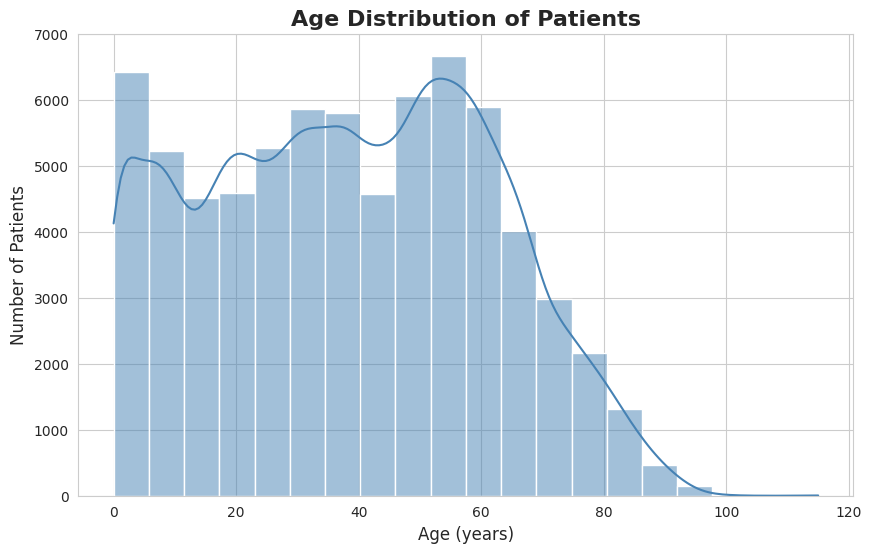

Chart saved!


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean visual style for all charts
sns.set_style('whitegrid')

# Create a figure with specified size (width=10, height=6 inches)
plt.figure(figsize=(10, 6))

# Draw a histogram of patient ages
# bins=20 means divide the range into 20 equal sections
# kde=True draws a smooth curve over the histogram
sns.histplot(data=df, x='age', bins=20, kde=True, color='steelblue')

# Add title and axis labels
plt.title('Age Distribution of Patients', fontsize=16, fontweight='bold')
plt.xlabel('Age (years)', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)

# Save the chart as an image file
plt.savefig('charts/age_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved!')


No-show rate by gender:
gender
F    28.4
M    28.7
Name: no_show_binary, dtype: float64


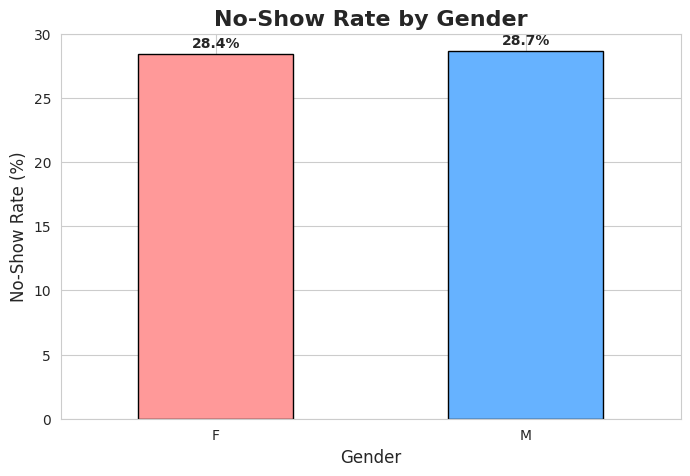

In [14]:
# Calculate no-show rate for each gender
# groupby splits the data into groups, then we calculate the mean of each group
gender_noshow = df.groupby('gender')['no_show_binary'].mean() * 100
print('No-show rate by gender:')
print(gender_noshow.round(1))

# Create a bar chart
plt.figure(figsize=(8, 5))
gender_noshow.plot(kind='bar', color=['#FF9999', '#66B2FF'], edgecolor='black')
plt.title('No-Show Rate by Gender', fontsize=16, fontweight='bold')
plt.xlabel('Gender', fontsize=12)
plt.ylabel('No-Show Rate (%)', fontsize=12)
plt.xticks(rotation=0)
plt.ylim(0, 30)     # Set y-axis from 0 to 30%

# Add value labels on top of each bar
for i, v in enumerate(gender_noshow):
    plt.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

plt.savefig('charts/noshow_by_gender.png', dpi=150, bbox_inches='tight')
plt.show()


No-show rate by SMS:
No SMS      29.4
SMS Sent    27.6
Name: no_show_binary, dtype: float64


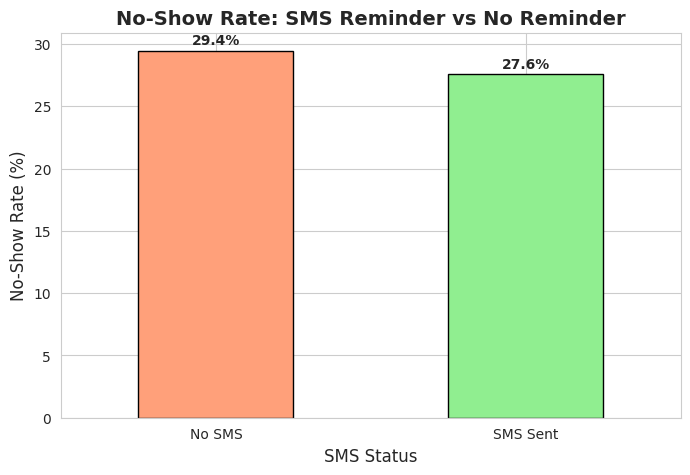

In [15]:

sms_noshow = df.groupby('sms_received')['no_show_binary'].mean() * 100


sms_noshow.index = ['No SMS', 'SMS Sent']
print('No-show rate by SMS:')
print(sms_noshow.round(1))


plt.figure(figsize=(8, 5))
sms_noshow.plot(kind='bar', color=['#FFA07A', '#90EE90'], edgecolor='black')
plt.title('No-Show Rate: SMS Reminder vs No Reminder', fontsize=14, fontweight='bold')
plt.xlabel('SMS Status', fontsize=12)
plt.ylabel('No-Show Rate (%)', fontsize=12)
plt.xticks(rotation=0)

for i, v in enumerate(sms_noshow):
    plt.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

plt.savefig('charts/noshow_by_sms.png', dpi=150, bbox_inches='tight')
plt.show()


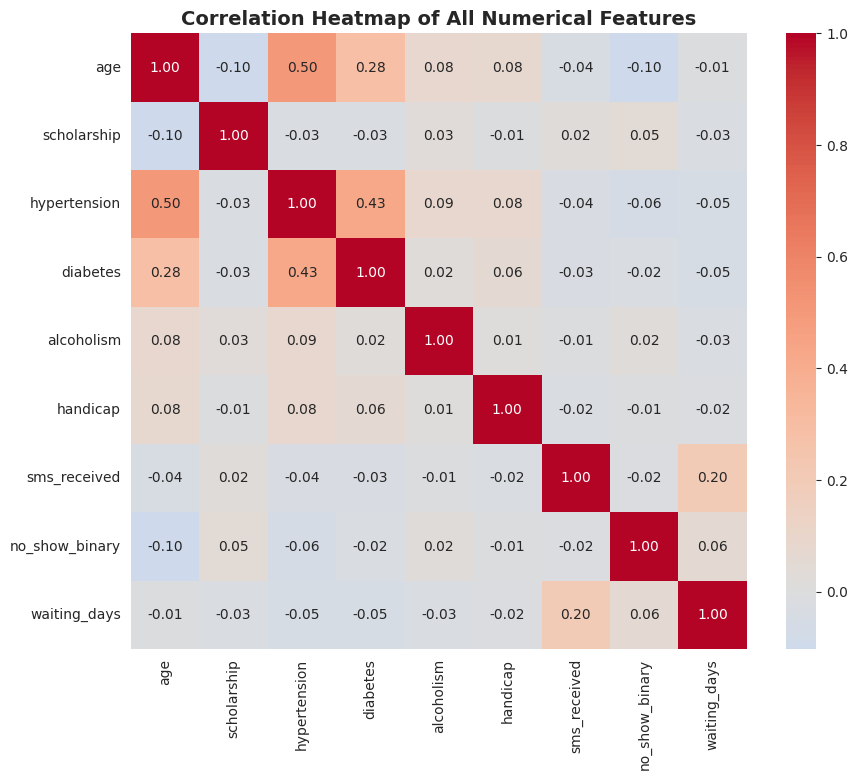

In [16]:
# Select only numerical columns for correlation
numerical_cols = ['age', 'scholarship', 'hypertension', 'diabetes',
                  'alcoholism', 'handicap', 'sms_received', 'no_show_binary', 'waiting_days']

# Calculate correlation matrix
corr_matrix = df[numerical_cols].corr()

# Create a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True
)
plt.title('Correlation Heatmap of All Numerical Features', fontsize=14, fontweight='bold')
plt.savefig('charts/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


In [17]:

df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 12, 17, 35, 60, 120],
    labels=['Child', 'Teen', 'Young Adult', 'Middle-Aged', 'Senior'],
    right=True    # includes the right boundary
)

print('Patients by age group:')
print(df['age_group'].value_counts().sort_index())


age_noshow = df.groupby('age_group')['no_show_binary'].mean() * 100
print('\nNo-show rate by age group:')
print(age_noshow.round(1))


Patients by age group:
age_group
Child          10222
Teen            3813
Young Adult    16568
Middle-Aged    25380
Senior         13845
Name: count, dtype: int64

No-show rate by age group:
age_group
Child          31.6
Teen           36.6
Young Adult    34.4
Middle-Aged    26.7
Senior         20.5
Name: no_show_binary, dtype: float64


/tmp/ipykernel_3430/4205504095.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_noshow = df.groupby('age_group')['no_show_binary'].mean() * 100


In [18]:

df['appointment_dayofweek'] = df['appointmentday'].dt.day_name()


day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
day_noshow = df.groupby('appointment_dayofweek')['no_show_binary'].mean() * 100
day_noshow = day_noshow.reindex(day_order)

print('No-show rate by day of week:')
print(day_noshow.round(1))


No-show rate by day of week:
appointment_dayofweek
Monday       30.2
Tuesday      28.7
Wednesday    27.1
Thursday     27.3
Friday       29.4
Saturday     29.0
Name: no_show_binary, dtype: float64


In [19]:
# Encode gender: Female = 0, Male = 1
df['gender_encoded'] = df['gender'].map({'F': 0, 'M': 1})


print(df[['gender', 'gender_encoded']].head(10))

# Save the feature-engineered dataset
df.to_csv('data/cleaned/medical_noshow_features.csv', index=False)
print('Feature-engineered dataset saved!')


   gender  gender_encoded
5       F               0
6       F               0
7       F               0
9       F               0
10      F               0
11      M               1
12      F               0
13      M               1
14      F               0
15      F               0
Feature-engineered dataset saved!


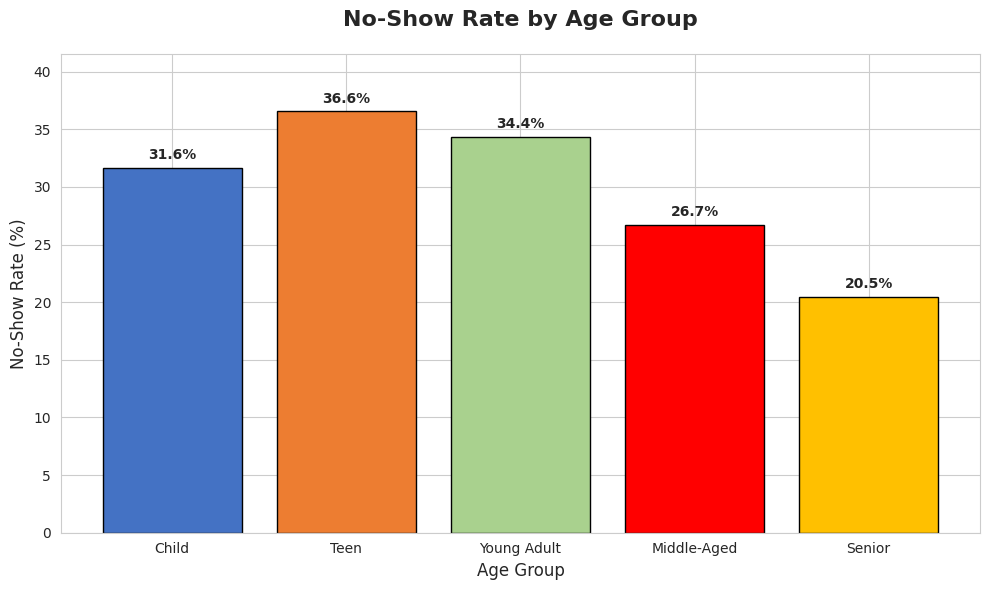

In [21]:
plt.figure(figsize=(10, 6))

age_noshow_sorted = df.groupby('age_group', observed=True)['no_show_binary'].mean() * 100

colors = ['#4472C4', '#ED7D31', '#A9D18E', '#FF0000', '#FFC000']
bars = plt.bar(
    age_noshow_sorted.index,
    age_noshow_sorted.values,
    color=colors,
    edgecolor='black'
)

# Add value labels
for bar, val in zip(bars, age_noshow_sorted.values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        f'{val:.1f}%',
        ha='center',
        va='bottom',
        fontweight='bold'
    )

plt.title(
    'No-Show Rate by Age Group',
    fontsize=16,
    fontweight='bold',
    pad=20  # extra space between title and plot
)

plt.xlabel('Age Group', fontsize=12)
plt.ylabel('No-Show Rate (%)', fontsize=12)

# Give headroom for labels
plt.ylim(0, max(age_noshow_sorted.values) + 5)

plt.tight_layout()

plt.savefig(
    'charts/noshow_by_age_group.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()


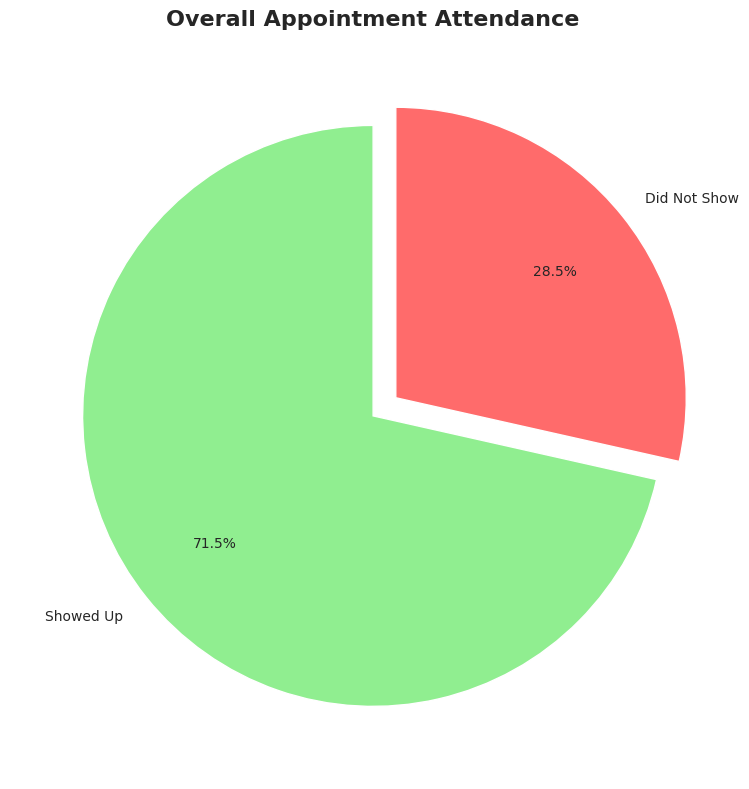

In [22]:
plt.figure(figsize=(8, 8))

# Count each value
noshow_counts = df['no_show'].value_counts()

labels = ['Showed Up', 'Did Not Show']
colors = ['#90EE90', '#FF6B6B']
explode = (0, 0.1)

plt.pie(
    noshow_counts.values,
    labels=labels,
    colors=colors,
    explode=explode,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.7
)

plt.title(
    'Overall Appointment Attendance',
    fontsize=16,
    fontweight='bold',
    pad=20
)

plt.tight_layout()

plt.savefig(
    'charts/attendance_pie.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

/tmp/ipykernel_3430/1895516.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


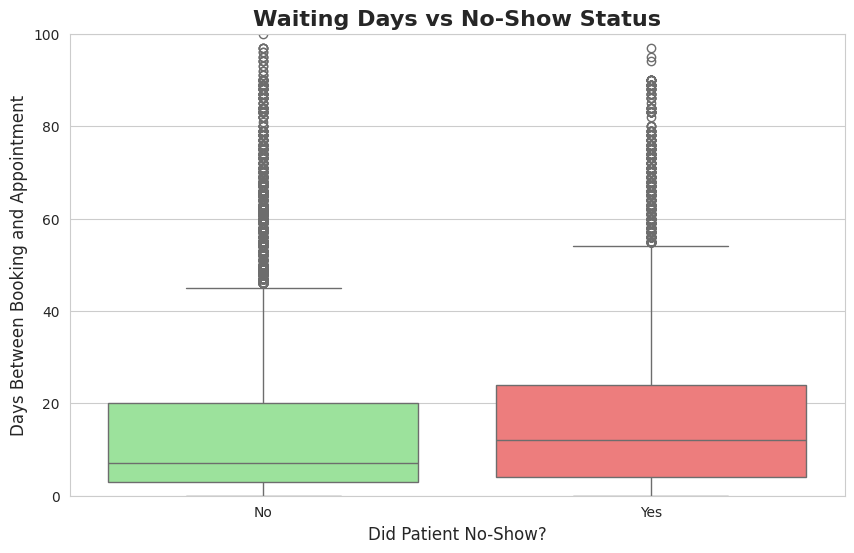

In [23]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df,
    x='no_show',
    y='waiting_days',
    palette=['#90EE90', '#FF6B6B']
)
plt.title('Waiting Days vs No-Show Status', fontsize=16, fontweight='bold')
plt.xlabel('Did Patient No-Show?', fontsize=12)
plt.ylabel('Days Between Booking and Appointment', fontsize=12)
plt.ylim(0, 100)    # Focus on 0-100 days range
plt.savefig('charts/waitingdays_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()


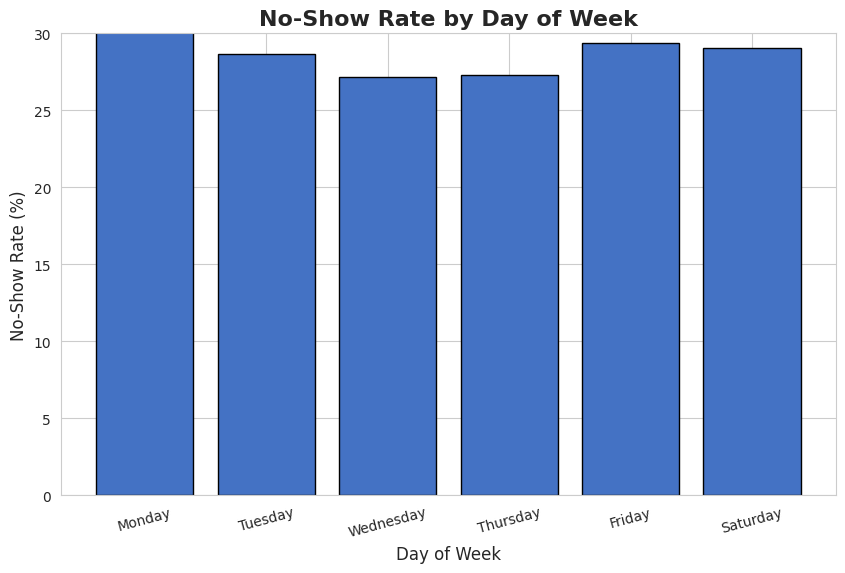

In [24]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
day_noshow = df.groupby('appointment_dayofweek')['no_show_binary'].mean() * 100
day_noshow = day_noshow.reindex(day_order)

plt.figure(figsize=(10, 6))
plt.bar(day_noshow.index, day_noshow.values, color='#4472C4', edgecolor='black')
plt.title('No-Show Rate by Day of Week', fontsize=16, fontweight='bold')
plt.xlabel('Day of Week', fontsize=12)
plt.ylabel('No-Show Rate (%)', fontsize=12)
plt.xticks(rotation=15)
plt.ylim(0, 30)
plt.savefig('charts/noshow_by_day.png', dpi=150, bbox_inches='tight')
plt.show()
